# Indian Stock Market Analysis

## Pre Requisite

In [441]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import pandas as pd
import yfinance as yf
from pandas_datareader import data as wb

## Nifty 50 (Market Index)

### Basic Data Loading

In [442]:
nf50=yf.download('^NSEI',start='2015-4-1',end='2026-4-1',auto_adjust=False)
nf50=pd.DataFrame(nf50)
nf50.columns = nf50.columns.droplevel("Ticker")
nf50.columns.name = None 
nf50.head()

[*********************100%***********************]  1 of 1 completed


,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2015-04-01,8586.250000,8586.250000,8603.400391,8464.750000,8483.700195,125500
2015-04-06,8659.900391,8659.900391,8667.549805,8573.750000,8615.799805,146900
2015-04-07,8660.299805,8660.299805,8693.599609,8586.849609,8684.450195,148700
2015-04-08,8714.400391,8714.400391,8730.500000,8679.799805,8698.950195,148200
2015-04-09,8778.299805,8778.299805,8785.500000,8682.450195,8756.200195,152700


In [443]:
nf50.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 2707 entries, 2015-04-01 to 2026-03-30
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Adj Close  2707 non-null   float64
 1   Close      2707 non-null   float64
 2   High       2707 non-null   float64
 3   Low        2707 non-null   float64
 4   Open       2707 non-null   float64
 5   Volume     2707 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 148.0 KB


### Returns

In [444]:
nf50['Percreturn']=nf50["Adj Close"].pct_change()
nf50['Logreturn']=np.log(nf50["Adj Close"]/nf50["Adj Close"].shift(1))
nf50.head()

,Adj Close,Close,High,Low,Open,Volume,Percreturn,Logreturn
Date,,,,,,,,
2015-04-01,8586.250000,8586.250000,8603.400391,8464.750000,8483.700195,125500,NaN,NaN
2015-04-06,8659.900391,8659.900391,8667.549805,8573.750000,8615.799805,146900,0.008578,0.008541
2015-04-07,8660.299805,8660.299805,8693.599609,8586.849609,8684.450195,148700,0.000046,0.000046
2015-04-08,8714.400391,8714.400391,8730.500000,8679.799805,8698.950195,148200,0.006247,0.006228
2015-04-09,8778.299805,8778.299805,8785.500000,8682.450195,8756.200195,152700,0.007333,0.007306


Text(0.5, 0, 'Year')

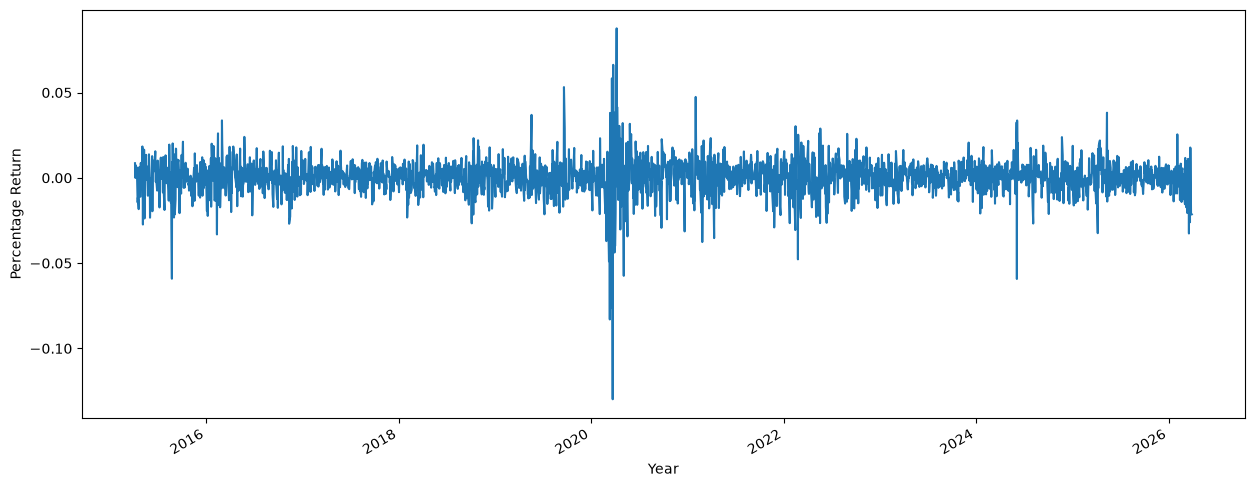

In [445]:
x=nf50['Percreturn'].plot(figsize=(15,6))
x.set_ylabel('Percentage Return')
x.set_xlabel('Year')

Text(0.5, 0, 'Year')

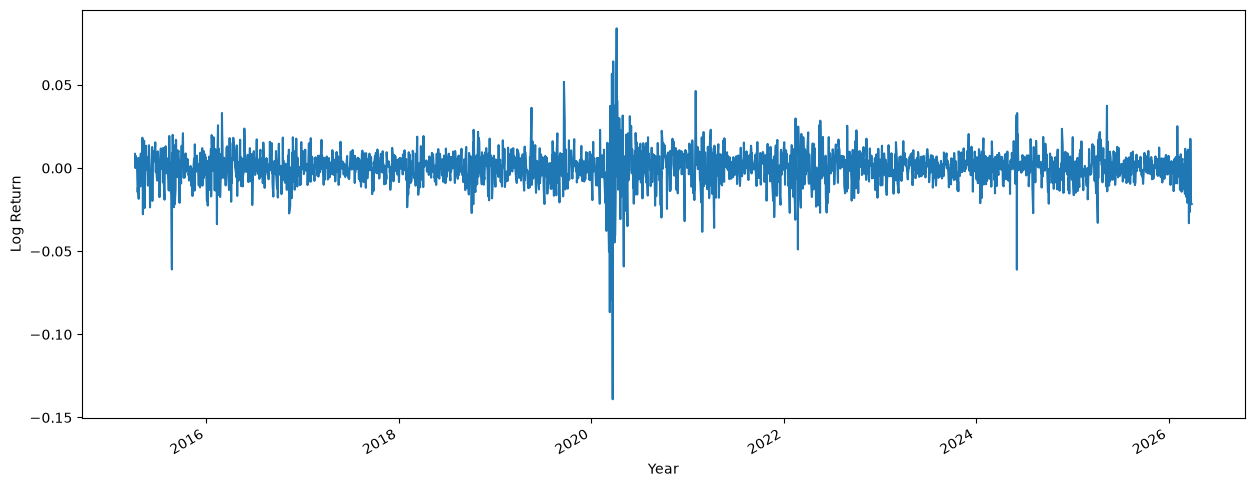

In [446]:
y=nf50['Logreturn'].plot(figsize=(15,6))
y.set_ylabel('Log Return')
y.set_xlabel('Year')

In [447]:
rm=nf50['Percreturn'].mean()
arm=rm*250
lrm=nf50['Logreturn'].mean()
alrm=lrm*250
print(f"Annual Simple Rate of Return:{arm}\nAnnual Logarithmic Rate of Return:{alrm}\n")

Annual Simple Rate of Return:0.10160533015060852
Annual Logarithmic Rate of Return:0.08830669722447852



### Volatility

In [448]:
rv=nf50['Percreturn'].std()
arv=rv*250**0.5
lrv=nf50['Logreturn'].std()
alrv=lrv*250**0.5
print(f"Annual Volatility:{arv}\n Annual Logarithmic Volatility:{alrv}\n")

Annual Volatility:0.16238082616719302
 Annual Logarithmic Volatility:0.16335679720886087



### Future Prediction(Historical Bootstrap- based on previous record)

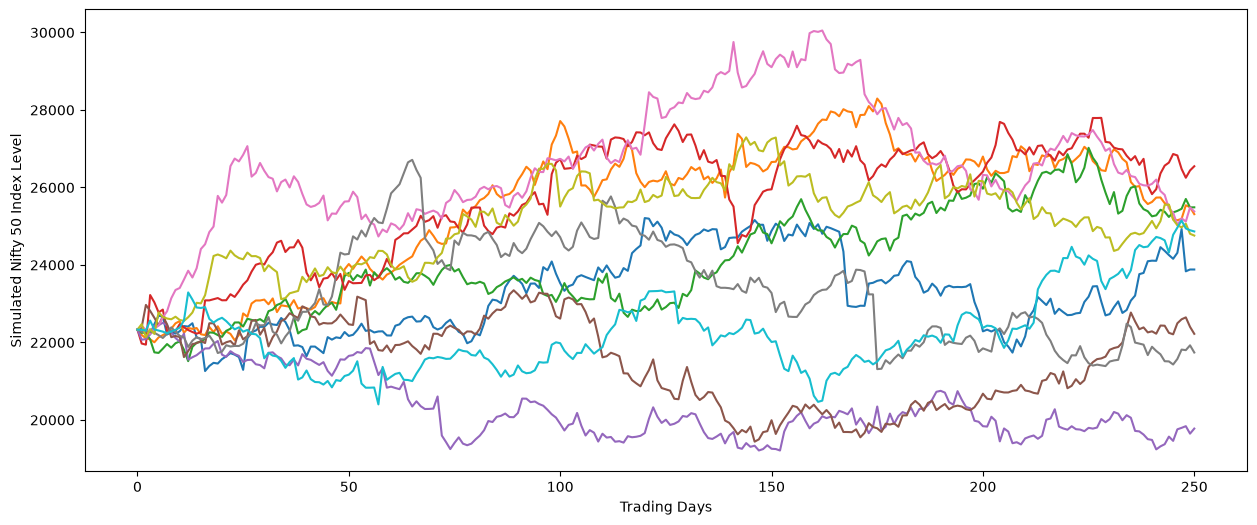

In [ ]:
historical_returns = nf50["Percreturn"].values
iterations=10000
t_interval=250
sampled_returns = np.random.choice(
    historical_returns,
    size=(t_interval, iterations),
    replace=True
)
s = np.zeros((t_interval + 1, iterations))
s0=nf50["Adj Close"].iloc[-1]
s[0] = s0
plt.close("all")
for t in range(1, t_interval + 1):
    s[t] = s[t-1] * (1 + sampled_returns[t-1])
plt.figure(figsize=(15,6))
plt.plot(s[:,:10])
plt.xlabel("Trading Days")
plt.ylabel("Simulated Nifty 50 Index Level")
plt.show()

### Future Prediction (Monte Carlo Simulation)

Text(0, 0.5, 'Simulated Nifty 50 Index Level')

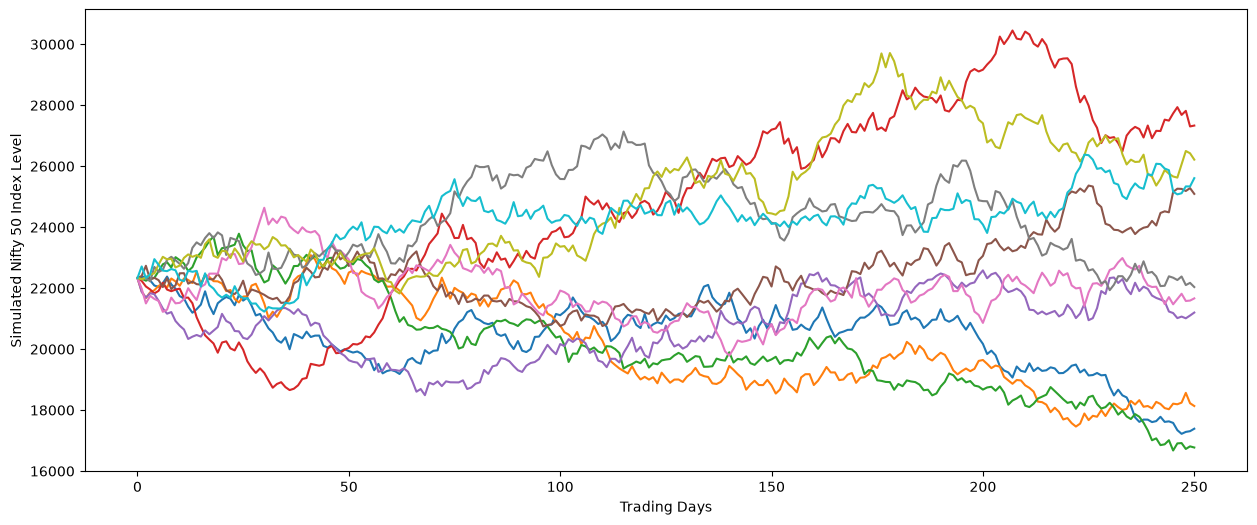

In [450]:
r=0.0721
st=alrv
iterations=10000
T=1.0
t_interval=250
delta=T/t_interval
z=np.random.standard_normal((t_interval+1,iterations))
s=np.zeros_like(z)
s0=nf50['Adj Close'].iloc[-1]
s[0]=s0
for t in range(1,t_interval+1):
  s[t]=s[t-1]*np.exp((r-0.5*(st**2))*delta+st*np.sqrt(delta)*z[t])
plt.figure(figsize=(15,6))
plt.plot(s[:,:10])
plt.xlabel("Trading Days")
plt.ylabel("Simulated Nifty 50 Index Level")